# Exercise 3 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Emma Radoslavova Anastassova

Sciper number: 414901

#### Group Member 2:
Name: Mattea Busato

Sciper number: 408744

#### Group Member 3:
Name: Taliesin Perez

Sciper number: 357587

#### Group Member 4:
Name: Simon David Guillaume Jacques PIERRE

Sciper number: 345594

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

In [2]:
### Do the imports -- no need to change this
import numpy as np
from typing import List
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

# Ex 1: Prove of the Policy Gradient Theorem via the Performance Difference Lemma (20 points)

Denote $J(\pi) = \langle \mu, V^\pi \rangle$ and recall that the performance difference lemma states
$$
J(\pi) - J(\pi') = \frac{1}{(1-\gamma)}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]
$$
where $\lambda^{\pi'} \in \Delta_{\mathcal{S}\times\mathcal{A}}$ denotes the occupancy measure of the policy $\pi'$.

Now let us consider direct parametization, and compute a partial derivative for the entry of $\pi$ at index $(\bar{s},\bar{a})$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}.
$$

**Questions**

To help you compute this partial derivative, consider the policies $\pi'$ parameterized by some (sufficiently small) $\delta \in \mathbb{R}$ via
$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

(1) Argue that
$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

**Answer**

(2) Argue that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).$$

Hint: Write the expectation in the previous question as a sum and use the fact that $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$.

**Answer**

(3) Conclude that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$$
for the direct parameterization. 

**Answer**

(4) Prove that for a general parametrization, it holds that
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{(1-\gamma)} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} ( \log \pi_\theta(\bar{a}|\bar{s}))
$$

Hint: Use the chain rule to write $$ \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}), $$
and then use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$.

**Answer**

# Ex 2: Natural Policy Gradient with softmax parameterization (20 points)

Recall that the iterates $\{\pi^t\}^{\infty}_{t=1}$ produced by NPG read as follows:
$$
\pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
$$

Implement NPG for an arbitrary step size $\eta$. Please note that $e^{\eta Q^{\pi^t}(s,a)}$ can be zero, account for that in your implementation.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [ ]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy stochastic passed with shape n_states times n_actions
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s].dot(pi[s])
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

def npg_update(q, eta, old_policy):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        new_policy: the updates policy
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s] = ??? # TODO (unnormalized update)
        total = np.sum(policy[s])
        if total == 0:
             policy[s] = np.ones(q.shape[1])/q.shape[1]
        else:
            policy[s] = ??? # TODO: normalize
    return policy

def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s,np.argmax(q[s,:])] = 1
    return policy

In [ ]:
def NPG(env, eta): # apply NPG iterations for 30 steps
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.ones_like(q)/env.n_actions
    for k in range(30):
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        if eta < np.inf:
            pi = npg_update(q, eta, pi)
        else:
            pi = get_greedy_policy(q)
        vs.append(v)
        policies.append(pi)
    return vs, policies

Now, we run NPG for different stepsizes in the usual gridworld environment

In [ ]:
reward_mode = 2
size = 10 
prop = 0
gamma=0.99
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
mu = np.ones(gridworld.n_states)/gridworld.n_states
etas = [1e-3, 1e-2, 1e-1, 1, 100, 1e7, np.inf]
v_different_etas = []
pi_different_etas = []
for eta in etas:
    values_pi, policies = NPG(gridworld, eta=eta)
    v_different_etas.append(values_pi)
    pi_different_etas.append(policies)

In [ ]:
solver = MDPsolver(gridworld)
solver.value_iteration()

In [ ]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

**Question**

Show that NPG with $\eta = \infty$ coincides with Policy Iteration (PI).

More formally: Assuming that $a^\star_s := \mathrm{argmax}_a Q^{\pi^t}(s,a)$ is unique for all $s$, prove that $$ \lim_{\eta \rightarrow \infty} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},$$
and explain how this relates to PI.

**Answer**

**Question**

Is this observation in line with the empirical results in the plot above? I.e., is the plot for $\eta = \infty$ as you would expect it for PI?

**Answer**

## Ex 2.2 Slow Changing Property of NPG

In this exercise you will investigate by how much consecutive iterates $\pi^t$ and $\pi^{t+1}$ produced by NPG differ and how this distance is controlled by the step size $\eta$.

Plot $$\max_{s \in \mathcal{S}} || \pi^{t+1}(a|s) - \pi^t(a|s) ||_1$$ for different values of $\eta$.

In [ ]:
def compute_policy_variation(policies):
    variation = []
    for pi, pip in zip(policies[1:], policies[:-1]):
        variation.append(np.max([ ??? for s in range(pi.shape[0])])) # TODO
    return variation

In [ ]:
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)]), 
               [f" eta = {eta}" for eta in etas], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

**Question**

Empirically, is the largest change (among all iterations) between consecutive iterations is larger for smaller or large values of $\eta$?

## Some Theory to Motivate the Observation Above

**Question**

Our goal is to prove that $$ || \pi^{t+1}(\cdot|s) - \pi^t(\cdot|s) ||_1 \leq \frac{\eta}{1 - \gamma} \quad \forall s \in \mathcal{S}, \forall t \in [T].$$

We guide you towards this result by breaking the proof into small steps.

1) Prove that $$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log \bigg(\sum_{a'\in\mathcal{A}} \pi^t(a'|s) \exp (\eta Q^{\pi^t}(s,a'))\bigg) $$

Hint: First apply Pinkser's inequality https://en.wikipedia.org/wiki/Pinsker%27s_inequality to prove that $$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq KL(\pi^{t+1}(s)||\pi^t(s)), $$ then plug in the formula for $\pi^{t+1}$ into the KL term.

**Answer**

2) Prove that 
$$
\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) = \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
$$

**Answer**

3) Using the results in 1) and 2) prove that 

$$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log \bigg(\sum_{a'\in\mathcal{A}} \pi^{t+1}(a'|s) \exp (-\eta Q^{\pi^t}(s,a'))\bigg). $$

**Answer**

4) Using Hoeffding's Lemma https://en.wikipedia.org/wiki/Hoeffding%27s_lemma (on the sum in the log term!) and the fact that $$-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma},$$ conclude that 
$$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \frac{\eta^2}{2 (1 - \gamma)^2}.$$

**Answer**

# Ex 3: OPPO: The importance of Exploration in Policy Gradient (20 points)

In this exercise, we will investigate how crucial it is to perform exploration. That is, adding bonuses to avoid suffering the mismatch coefficients in the convergence bounds.

Let us recall that the standard sample based version of NPG suffers the mismatch coeffcients in the bounds (see Slide 22 in Lecture 5). Those are avoided by OPPO ( See slide 30 in Lecture 5 ).

**To see clearly the advatange of OPPO we will consider an MDP with unbounded mismatch coefficients**

**Question: example of unbounded mismatch coefficients**

Consider a 10 x 10 gridworld, the initial state is always the bottom right corner, i.e. the initial distribution $\mu$ equals $1$ at this starting state and it is zero everywhere else. Can you compute a finite bound for 
$$\max_\pi \max_{s \in \mathcal{S}} \bigg |\frac{\lambda^\pi(s)}{\mu(s)} \bigg|,$$
i.e. the mismatch coefficient? If not, argue for which reason.

**Answer**



In the following, we experiment with OPPO with and without bonuses in this environment.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [ ]:
reward_mode = 0
size = 10
gamma=0.999
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

In [ ]:
from copy import deepcopy
np.random.seed(0)
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=5) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states, 
                                     gridworld.n_actions, 
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):
            #NPG Update
            policy[h, state, :] = ??? # TODO (unnormalized)
            
            total = np.sum(policy[h, state, :])
            if total == 0 or np.any(np.isnan(policy[h, state, :])):
                policy[h, state, :] = ??? # TODO: fallback to a uniform distribution
            else:
                policy[h, state, :] = ??? # TODO: normalize

            # Sample one action the current policy
            a = np.random.choice(gridworld.n_actions, p=???) # TODO
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += ??? # TODO

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += ??? # TODO
            
            # Update empirical transition estimate
            estimated_transitions[h,state,a,:] = ??? # TODO
            
            state = new_state
                    
        # Calculate the UCB bonus
        bonus = ???

        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm
            Q_new[h] = ??? # TODO

            # Update V as the Q-value of the optimal actions for the current state
            for state in range(gridworld.n_states):
                V_new[h, state] = ??? # TODO
        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [ ]:
to_plot = []
betas = [0, 1e-5, 1e-3, 0.1, 10]

for beta in betas:
    print(beta)
    reward_OPPO = oppo(beta = beta)  # You can play around with the arguments if you like
    to_plot.append(np.cumsum(reward_OPPO))

In [ ]:
labels = [ f"OPPO beta = {beta}" for beta in betas]
plot_lines(
    to_plot,
    labels,
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=False
)

**Question**

Why does setting $\beta = 0$ lead to bad results? 

*Hint: Explain using the remarks in slide 28 and the theoretical bound in Slide 22 of Lecture 5*.

**Answer**

**Question**

Why does setting $\beta$ too large lead to poor results?

*Hint: Answer using the regret bound for OPPO given at the beginning of slide 30.*

**Answer**

# Ex 4: REINFORCE with parametrized policies (20 points)

In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages

In [18]:
!pip install "numpy<1.24"

     |████████████████████████████████| 13.4 MB 21.3 MB/s eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
You should consider upgrading via the '/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/bin/python3 -m pip install --upgrade pip' command.


In [3]:
# TODO: you may need to run this to make sure to have the correct versions
!pip install gym==0.25.2
!pip install gym-notices==0.0.8

     |████████████████████████████████| 734 kB 2.1 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Created wheel for gym: filename=gym-0.25.2-py3-none-any.whl size=852395 sha256=3ca2c9c6be0e7c16581793bfbbf8e3139114bd0b56712d260e4e10cc5aeb008d
  Stored in directory: /Users/matteabusato/Library/Caches/pip/wheels/05/4d/6c/d0ef0db36695ce032fe20099e3149d8db85cf36656176ff745
Successfully built gym
You should consider upgrading via the '/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/bin/python3 -m pip install --upgrade pip' command.
  Attempting uninstall: gym-notices
    Found existing installation: gym-notices 0.1.0
    Uninstalling gym-notices-0.1.0:
      Successfully uninstalled gym-notices-0.1.0
You should consider upgrading via the '/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/bin/python3 -m pip install --upgrade pip' command.


In [20]:
import gym
# Run once at the top of the notebook, before `import gym`
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

In [6]:
env = gym.make('CartPole-v0')
env.seed(0)

/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

[0]

In [7]:
class Policy(nn.Module): # definie the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)
    

In [8]:
# REINFORCE (with reward-to-go)
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.

**Answer**

In [ ]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
  angle = state[2]
  value = 100*(0.25-angle**2) # TO BE CHANGED USING YOUR BASELINE
  return value

def baseline_1(state): # TO BE CHANGED USING YOUR BASELINE 1
  cart_velocity = state[1]
  value = 20 * (1 - (cart_velocity/3.0)**2)  
  return max(value, 0)

def baseline_2(state): # TO BE CHANGED USING YOUR BASELINE 2
  cart_position = state[0]
  value = 50 * (1 - (cart_position/2.4)**2)
  return value

# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

### Sweep of parameters for baseline 1:

Baseline 1 that we want to try out is formulated as:
$$b(s) = \max \Bigg(0, a*\bigg( 1 -  {\mid \frac{v}{c}\mid} \bigg)^d \Bigg)$$

with:
- $v$ being the cart's velocity
- $a$ being the amplitude
- $b$ is a redundant constant, let's make it $1$
- $c$ is the velocity rescale 
- $d$ is the shape exponent

We will also sweep the learning rates.


In [63]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import gym
import random
import time
import matplotlib.pyplot as plt
from itertools import product

def make_baseline_1(a, b_const, c, d):
    """Factory: returns a baseline closure with the given hyperparameters."""
    def baseline_1(state):
        cart_velocity = state[1]
        value = a * (b_const - (cart_velocity / c) ** d)
        return max(value, 0)
    return baseline_1


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_one_config(a, b_const, c, d, lr, seed, n_episodes):
    """One run: returns the full scores array."""
    set_all_seeds(seed)
    env_local = gym.make('CartPole-v0')
    env_local.seed(seed)
    
    global env
    env = env_local
    
    baseline_fn = make_baseline_1(a, b_const, c, d)
    policy = Policy().to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    
    scores = reinforce_rwd2go_baseline(
        policy, optimizer, baseline=baseline_fn,
        early_stop=False, n_episodes=n_episodes, gamma=1.0,
        print_every=10**9   # silence per-run output
    )
    return np.array(scores)


def evaluate_config(a, b_const, c, d, lr, seeds, n_episodes):
    """Run a config across multiple seeds, return summary metrics."""
    all_scores = []
    for s in seeds:
        scores = run_one_config(a, b_const, c, d, lr, seed=s, n_episodes=n_episodes)
        all_scores.append(scores)
    
    min_len = min(len(s) for s in all_scores)
    arr = np.stack([s[:min_len] for s in all_scores])   # shape (n_seeds, n_episodes)
    
    final_window = arr[:, -100:].mean(axis=1)
    mean_final   = final_window.mean()
    std_final    = final_window.std()
    
    eps_to_solve = []
    for row in arr:
        if len(row) >= 100:
            running = np.convolve(row, np.ones(100)/100, mode='valid')
            idx = np.where(running >= 195.0)[0]
            eps_to_solve.append(idx[0] + 100 if len(idx) else np.nan)
        else:
            eps_to_solve.append(np.nan)
    mean_eps_to_solve = np.nanmean(eps_to_solve)
    
    auc = arr.mean(axis=0).sum()  # area under mean curve = total reward across training
    
    return {
        'mean_final': mean_final,
        'std_final': std_final,
        'eps_to_solve': mean_eps_to_solve,
        'auc': auc,
        'all_scores': arr,
    }


def run_sweep(grid, seeds, n_episodes, label='sweep'):
    """grid is a list of dicts {a, b_const, c, d, lr}."""
    rows = []
    t0 = time.time()
    for i, cfg in enumerate(grid):
        print(f'[{label}] {i+1}/{len(grid)}  {cfg}  (elapsed {time.time()-t0:.0f}s)')
        try:
            metrics = evaluate_config(**cfg, seeds=seeds, n_episodes=n_episodes)
            row = {**cfg, **{k: v for k, v in metrics.items() if k != 'all_scores'}}
            row['scores'] = metrics['all_scores']
            rows.append(row)
        except Exception as e:
            print(f'  FAILED: {e}')
            rows.append({**cfg, 'mean_final': np.nan, 'std_final': np.nan,
                         'eps_to_solve': np.nan, 'auc': np.nan, 'scores': None})
    return pd.DataFrame(rows)

In [64]:
from itertools import product

stage1_grid = [
    {'a': a, 'b_const': 1.0, 'c': c, 'd': 2.0, 'lr': lr}
    for a, c, lr in product(
        [20, 50, 100],
        [2.0, 4.0],
        [1e-3, 3e-3, 1e-2],
    )
]
print(f'Stage 1: {len(stage1_grid)} configurations')

stage1_results = run_sweep(stage1_grid, seeds=[0, 1, 2], n_episodes=500, label='stage1')
print(stage1_results[['a','c','lr','mean_final','std_final','eps_to_solve','auc']]
      .sort_values('auc', ascending=False).to_string())

Stage 1: 18 configurations
[stage1] 1/18  {'a': 20, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.001}  (elapsed 0s)


/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

[stage1] 2/18  {'a': 20, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.003}  (elapsed 8s)
[stage1] 3/18  {'a': 20, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.01}  (elapsed 24s)
[stage1] 4/18  {'a': 20, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.001}  (elapsed 51s)
[stage1] 5/18  {'a': 20, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.003}  (elapsed 63s)
[stage1] 6/18  {'a': 20, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.01}  (elapsed 90s)
[stage1] 7/18  {'a': 50, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.001}  (elapsed 120s)
[stage1] 8/18  {'a': 50, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.003}  (elapsed 124s)
[stage1] 9/18  {'a': 50, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.01}  (elapsed 126s)
[stage1] 10/18  {'a': 50, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.001}  (elapsed 129s)
[stage1] 11/18  {'a': 50, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.003}  (elapsed 133s)
[stage1] 12/18  {'a': 50, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.01}  (elapsed 138s)
[stage1] 13/18  {

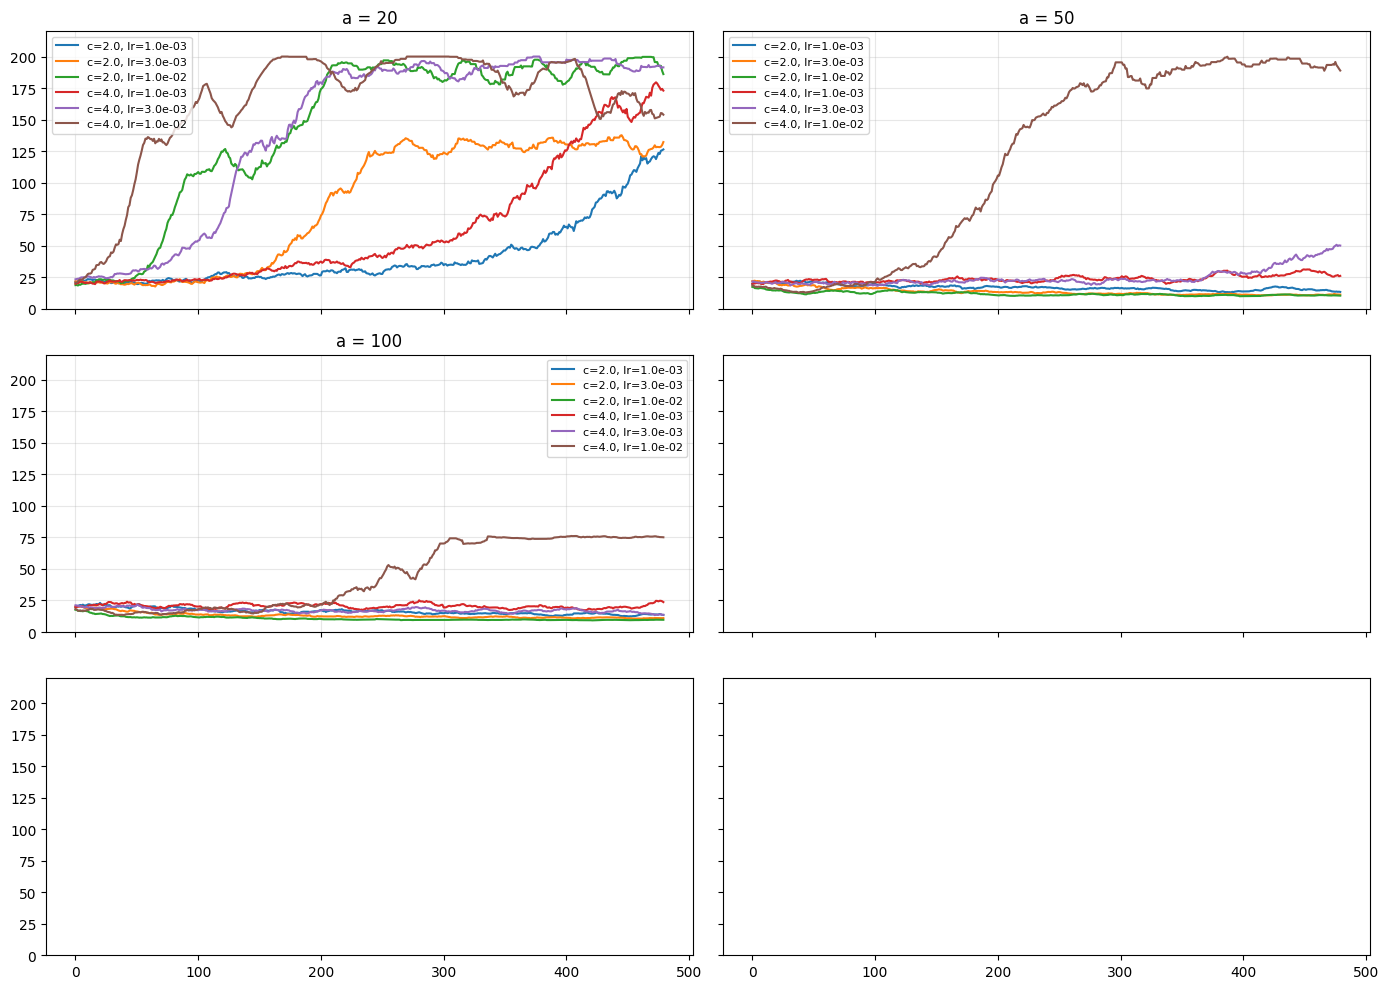

In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey=True)
for ax, (a_val, group) in zip(axes.ravel(),
                              stage1_results.groupby('a')):
    for _, row in group.iterrows():
        if row['scores'] is None: continue
        smoothed = np.convolve(row['scores'].mean(axis=0), np.ones(20)/20, mode='valid')
        ax.plot(smoothed, label=f"c={row['c']}, lr={row['lr']:.1e}")
    ax.set_title(f'a = {a_val}')
    ax.set_ylim(0, 220)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [66]:
# Take the top configurations from stage 1 and sweep d around them
top_configs = stage1_results.sort_values('auc', ascending=False).head(3)
print('Top configs from stage 1:')
print(top_configs[['a','c','lr','mean_final','auc']])

stage2_grid = []
for _, row in top_configs.iterrows():
    for d_val in [1.0, 2.0, 4.0]:
        # Also nudge a and c in case stage 1 missed the local optimum
        for a_mult, c_mult in [(0.7, 1.0), (1.0, 1.0), (1.4, 1.0),
                               (1.0, 0.7), (1.0, 1.4)]:
            stage2_grid.append({
                'a': row['a'] * a_mult,
                'b_const': 1.0,
                'c': row['c'] * c_mult,
                'd': d_val,
                'lr': row['lr'],
            })

# Deduplicate
seen = set()
unique_grid = []
for cfg in stage2_grid:
    key = (round(cfg['a'],2), round(cfg['c'],2), round(cfg['d'],2), cfg['lr'])
    if key not in seen:
        seen.add(key); unique_grid.append(cfg)

print(f'Stage 2: {len(unique_grid)} configurations')
stage2_results = run_sweep(unique_grid, seeds=[0,1,2,3,4], n_episodes=2000, label='stage2')
print(stage2_results[['a','c','d','lr','mean_final','std_final','eps_to_solve','auc']]
      .sort_values('auc', ascending=False).to_string())

Top configs from stage 1:
    a    c     lr  mean_final      auc
5  20  4.0  0.010  169.540000  80341.0
2  20  2.0  0.010  189.590000  72038.0
4  20  4.0  0.003  193.943333  70840.0
Stage 2: 42 configurations
[stage2] 1/42  {'a': 14.0, 'b_const': 1.0, 'c': 4.0, 'd': 1.0, 'lr': 0.01}  (elapsed 0s)


/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

[stage2] 2/42  {'a': 20.0, 'b_const': 1.0, 'c': 4.0, 'd': 1.0, 'lr': 0.01}  (elapsed 152s)
[stage2] 3/42  {'a': 28.0, 'b_const': 1.0, 'c': 4.0, 'd': 1.0, 'lr': 0.01}  (elapsed 238s)


/var/folders/v2/b77k8_mn6f141jgs0b7vf3hr0000gn/T/ipykernel_60001/1779787537.py:71: RuntimeWarning: Mean of empty slice
  mean_eps_to_solve = np.nanmean(eps_to_solve)


[stage2] 4/42  {'a': 20.0, 'b_const': 1.0, 'c': 2.8, 'd': 1.0, 'lr': 0.01}  (elapsed 264s)
[stage2] 5/42  {'a': 20.0, 'b_const': 1.0, 'c': 5.6, 'd': 1.0, 'lr': 0.01}  (elapsed 295s)
[stage2] 6/42  {'a': 14.0, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.01}  (elapsed 444s)
[stage2] 7/42  {'a': 20.0, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.01}  (elapsed 684s)
[stage2] 8/42  {'a': 28.0, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.01}  (elapsed 895s)
[stage2] 9/42  {'a': 20.0, 'b_const': 1.0, 'c': 2.8, 'd': 2.0, 'lr': 0.01}  (elapsed 1122s)
[stage2] 10/42  {'a': 20.0, 'b_const': 1.0, 'c': 5.6, 'd': 2.0, 'lr': 0.01}  (elapsed 1352s)
[stage2] 11/42  {'a': 14.0, 'b_const': 1.0, 'c': 4.0, 'd': 4.0, 'lr': 0.01}  (elapsed 1574s)
[stage2] 12/42  {'a': 20.0, 'b_const': 1.0, 'c': 4.0, 'd': 4.0, 'lr': 0.01}  (elapsed 1786s)
[stage2] 13/42  {'a': 28.0, 'b_const': 1.0, 'c': 4.0, 'd': 4.0, 'lr': 0.01}  (elapsed 1998s)
[stage2] 14/42  {'a': 20.0, 'b_const': 1.0, 'c': 2.8, 'd': 4.0, 'lr': 0.01}  (ela

In [67]:
best = stage2_results.sort_values('auc', ascending=False).iloc[0]
print('Best configuration:')
print(f"  a = {best['a']}, b_const = 1.0, c = {best['c']}, d = {best['d']}, lr = {best['lr']}")
print(f"  Final reward (mean over 5 seeds, last 100 episodes): {best['mean_final']:.1f} ± {best['std_final']:.1f}")
print(f"  Episodes to solve (mean over 5 seeds): {best['eps_to_solve']:.0f}")

Best configuration:
  a = 14.0, b_const = 1.0, c = 4.0, d = 2.0, lr = 0.01
  Final reward (mean over 5 seeds, last 100 episodes): 199.7 ± 0.6
  Episodes to solve (mean over 5 seeds): 387


In [77]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import gym
import random
import time
import matplotlib.pyplot as plt
from itertools import product

def make_baseline_2(a, b_const, c, d):
    """Factory: returns a baseline closure with the given hyperparameters."""
    def baseline_2(state):
        cart_position = state[0]
        value = a * (b_const - (cart_position / c) ** d)
        return value
    return baseline_2


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_one_config(a, b_const, c, d, lr, seed, n_episodes):
    """One run: returns the full scores array."""
    set_all_seeds(seed)
    env_local = gym.make('CartPole-v0')
    env_local.seed(seed)
    
    global env
    env = env_local
    
    baseline_fn = make_baseline_2(a, b_const, c, d)
    policy = Policy().to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    
    scores = reinforce_rwd2go_baseline(
        policy, optimizer, baseline=baseline_fn,
        early_stop=False, n_episodes=n_episodes, gamma=1.0,
        print_every=10**9   # silence per-run output
    )
    return np.array(scores)


def evaluate_config(a, b_const, c, d, lr, seeds, n_episodes):
    """Run a config across multiple seeds, return summary metrics."""
    all_scores = []
    for s in seeds:
        scores = run_one_config(a, b_const, c, d, lr, seed=s, n_episodes=n_episodes)
        all_scores.append(scores)
    
    min_len = min(len(s) for s in all_scores)
    arr = np.stack([s[:min_len] for s in all_scores])   # shape (n_seeds, n_episodes)
    
    final_window = arr[:, -100:].mean(axis=1)
    mean_final   = final_window.mean()
    std_final    = final_window.std()
    
    eps_to_solve = []
    for row in arr:
        if len(row) >= 100:
            running = np.convolve(row, np.ones(100)/100, mode='valid')
            idx = np.where(running >= 195.0)[0]
            eps_to_solve.append(idx[0] + 100 if len(idx) else np.nan)
        else:
            eps_to_solve.append(np.nan)
    mean_eps_to_solve = np.nanmean(eps_to_solve)
    
    auc = arr.mean(axis=0).sum()  # area under mean curve = total reward across training
    
    return {
        'mean_final': mean_final,
        'std_final': std_final,
        'eps_to_solve': mean_eps_to_solve,
        'auc': auc,
        'all_scores': arr,
    }


def run_sweep(grid, seeds, n_episodes, label='sweep'):
    """grid is a list of dicts {a, b_const, c, d, lr}."""
    rows = []
    t0 = time.time()
    for i, cfg in enumerate(grid):
        print(f'[{label}] {i+1}/{len(grid)}  {cfg}  (elapsed {time.time()-t0:.0f}s)')
        try:
            metrics = evaluate_config(**cfg, seeds=seeds, n_episodes=n_episodes)
            row = {**cfg, **{k: v for k, v in metrics.items() if k != 'all_scores'}}
            row['scores'] = metrics['all_scores']
            rows.append(row)
        except Exception as e:
            print(f'  FAILED: {e}')
            rows.append({**cfg, 'mean_final': np.nan, 'std_final': np.nan,
                         'eps_to_solve': np.nan, 'auc': np.nan, 'scores': None})
    return pd.DataFrame(rows)

In [74]:
from itertools import product

stage1_grid = [
    {'a': a, 'b_const': 1.0, 'c': c, 'd': 2.0, 'lr': lr}
    for a, c, lr in product(
        [20, 50, 100],
        [2.0, 4.0],
        [1e-3, 3e-3, 1e-2],
    )
]
print(f'Stage 1: {len(stage1_grid)} configurations')

stage1_results = run_sweep(stage1_grid, seeds=[0, 1, 2], n_episodes=500, label='stage1')
print(stage1_results[['a','c','lr','mean_final','std_final','eps_to_solve','auc']]
      .sort_values('auc', ascending=False).to_string())

Stage 1: 18 configurations
[stage1] 1/18  {'a': 20, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.001}  (elapsed 0s)


/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

[stage1] 2/18  {'a': 20, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.003}  (elapsed 8s)
[stage1] 3/18  {'a': 20, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.01}  (elapsed 24s)
[stage1] 4/18  {'a': 20, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.001}  (elapsed 52s)
[stage1] 5/18  {'a': 20, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.003}  (elapsed 64s)
[stage1] 6/18  {'a': 20, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.01}  (elapsed 91s)
[stage1] 7/18  {'a': 50, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.001}  (elapsed 122s)
[stage1] 8/18  {'a': 50, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.003}  (elapsed 125s)
[stage1] 9/18  {'a': 50, 'b_const': 1.0, 'c': 2.0, 'd': 2.0, 'lr': 0.01}  (elapsed 128s)
[stage1] 10/18  {'a': 50, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.001}  (elapsed 130s)
[stage1] 11/18  {'a': 50, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.003}  (elapsed 135s)
[stage1] 12/18  {'a': 50, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.01}  (elapsed 140s)
[stage1] 13/18  {

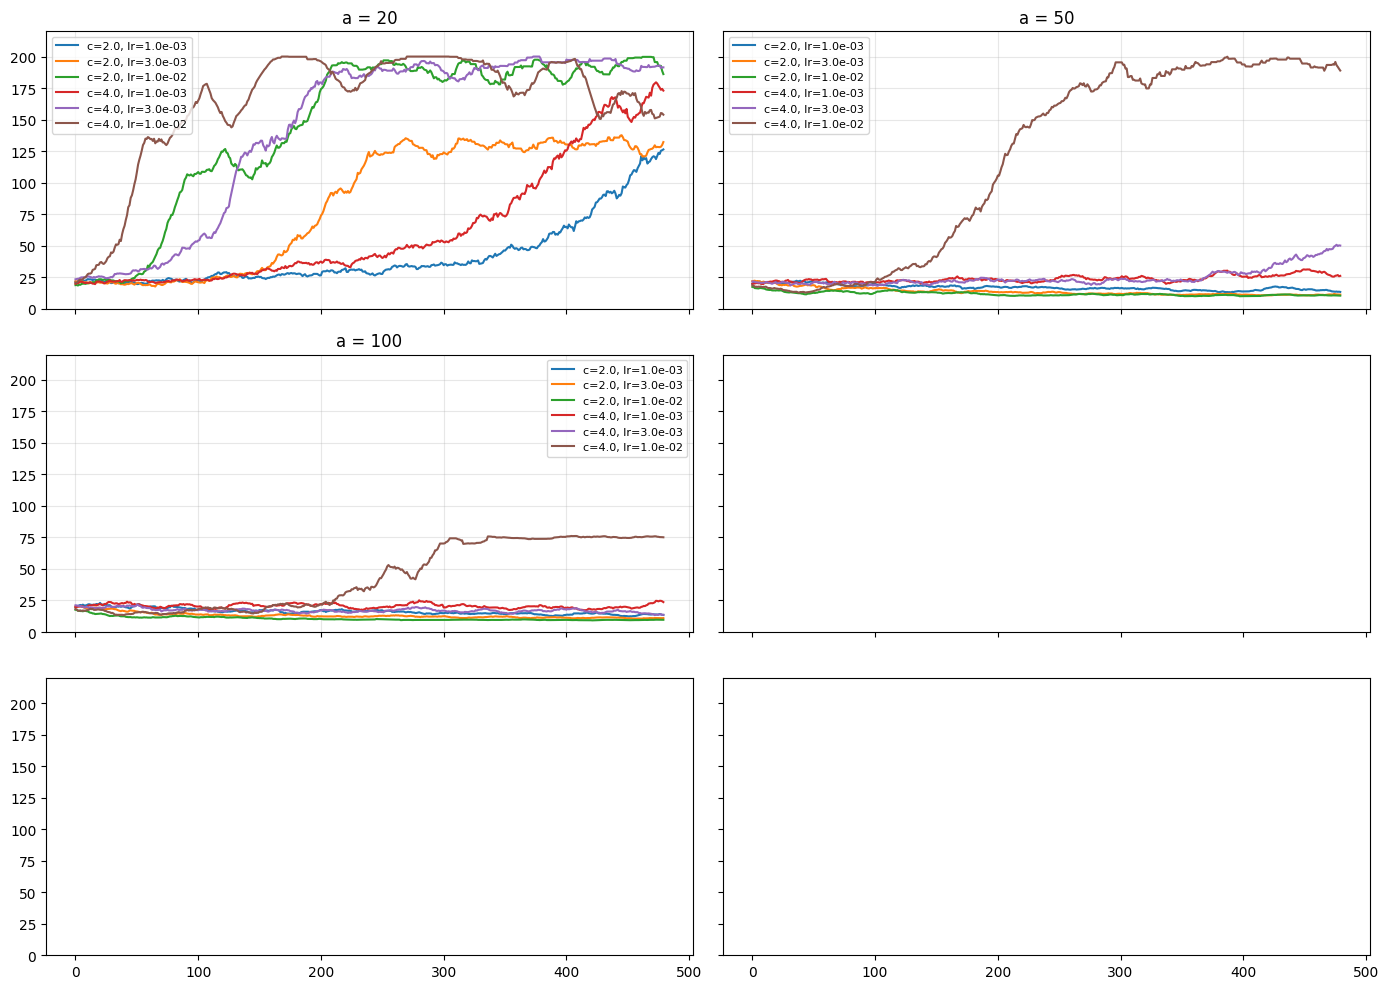

In [75]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey=True)
for ax, (a_val, group) in zip(axes.ravel(),
                              stage1_results.groupby('a')):
    for _, row in group.iterrows():
        if row['scores'] is None: continue
        smoothed = np.convolve(row['scores'].mean(axis=0), np.ones(20)/20, mode='valid')
        ax.plot(smoothed, label=f"c={row['c']}, lr={row['lr']:.1e}")
    ax.set_title(f'a = {a_val}')
    ax.set_ylim(0, 220)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [76]:
# Take the top configurations from stage 1 and sweep d around them
top_configs = stage1_results.sort_values('auc', ascending=False).head(3)
print('Top configs from stage 1:')
print(top_configs[['a','c','lr','mean_final','auc']])

stage2_grid = []
for _, row in top_configs.iterrows():
    for d_val in [1.0, 2.0, 4.0]:
        # Also nudge a and c in case stage 1 missed the local optimum
        for a_mult, c_mult in [(0.7, 1.0), (1.0, 1.0), (1.4, 1.0),
                               (1.0, 0.7), (1.0, 1.4)]:
            stage2_grid.append({
                'a': row['a'] * a_mult,
                'b_const': 1.0,
                'c': row['c'] * c_mult,
                'd': d_val,
                'lr': row['lr'],
            })

# Deduplicate
seen = set()
unique_grid = []
for cfg in stage2_grid:
    key = (round(cfg['a'],2), round(cfg['c'],2), round(cfg['d'],2), cfg['lr'])
    if key not in seen:
        seen.add(key); unique_grid.append(cfg)

print(f'Stage 2: {len(unique_grid)} configurations')
stage2_results = run_sweep(unique_grid, seeds=[0,1,2,3,4], n_episodes=2000, label='stage2')
print(stage2_results[['a','c','d','lr','mean_final','std_final','eps_to_solve','auc']]
      .sort_values('auc', ascending=False).to_string())

Top configs from stage 1:
    a    c     lr  mean_final      auc
5  20  4.0  0.010  169.540000  80341.0
2  20  2.0  0.010  189.590000  72038.0
4  20  4.0  0.003  193.943333  70840.0
Stage 2: 42 configurations
[stage2] 1/42  {'a': 14.0, 'b_const': 1.0, 'c': 4.0, 'd': 1.0, 'lr': 0.01}  (elapsed 0s)


/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

[stage2] 2/42  {'a': 20.0, 'b_const': 1.0, 'c': 4.0, 'd': 1.0, 'lr': 0.01}  (elapsed 152s)
[stage2] 3/42  {'a': 28.0, 'b_const': 1.0, 'c': 4.0, 'd': 1.0, 'lr': 0.01}  (elapsed 237s)


/var/folders/v2/b77k8_mn6f141jgs0b7vf3hr0000gn/T/ipykernel_60001/3271042782.py:71: RuntimeWarning: Mean of empty slice
  mean_eps_to_solve = np.nanmean(eps_to_solve)


[stage2] 4/42  {'a': 20.0, 'b_const': 1.0, 'c': 2.8, 'd': 1.0, 'lr': 0.01}  (elapsed 262s)
[stage2] 5/42  {'a': 20.0, 'b_const': 1.0, 'c': 5.6, 'd': 1.0, 'lr': 0.01}  (elapsed 293s)
[stage2] 6/42  {'a': 14.0, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.01}  (elapsed 441s)
[stage2] 7/42  {'a': 20.0, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.01}  (elapsed 677s)
[stage2] 8/42  {'a': 28.0, 'b_const': 1.0, 'c': 4.0, 'd': 2.0, 'lr': 0.01}  (elapsed 878s)
[stage2] 9/42  {'a': 20.0, 'b_const': 1.0, 'c': 2.8, 'd': 2.0, 'lr': 0.01}  (elapsed 1096s)
[stage2] 10/42  {'a': 20.0, 'b_const': 1.0, 'c': 5.6, 'd': 2.0, 'lr': 0.01}  (elapsed 1324s)
[stage2] 11/42  {'a': 14.0, 'b_const': 1.0, 'c': 4.0, 'd': 4.0, 'lr': 0.01}  (elapsed 1553s)
[stage2] 12/42  {'a': 20.0, 'b_const': 1.0, 'c': 4.0, 'd': 4.0, 'lr': 0.01}  (elapsed 1771s)
[stage2] 13/42  {'a': 28.0, 'b_const': 1.0, 'c': 4.0, 'd': 4.0, 'lr': 0.01}  (elapsed 1988s)
[stage2] 14/42  {'a': 20.0, 'b_const': 1.0, 'c': 2.8, 'd': 4.0, 'lr': 0.01}  (ela

In [ ]:
best = stage2_results.sort_values('auc', ascending=False).iloc[0]
print('Best configuration:')
print(f"  a = {best['a']}, b_const = 1.0, c = {best['c']}, d = {best['d']}, lr = {best['lr']}")
print(f"  Final reward (mean over 5 seeds, last 100 episodes): {best['mean_final']:.1f} ± {best['std_final']:.1f}")
print(f"  Episodes to solve (mean over 5 seeds): {best['eps_to_solve']:.0f}")

In [71]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
  angle = state[2]
  value = 100*(0.25-angle**2) # TO BE CHANGED USING YOUR BASELINE
  return value

def baseline_1(state): # TO BE CHANGED USING YOUR BASELINE 1
  cart_velocity = state[1]
  value = 14 * (1 - (cart_velocity/4.0)**2)  
  return max(value, 0)

def baseline_2(state): # TO BE CHANGED USING YOUR BASELINE 2
  cart_position = state[0]
  value = 50 * (1 - (cart_position/2.4)**2)
  return value

# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

In [69]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=False, n_episodes=2000)

/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

Episode 100	Average Score: 58.60
Episode 200	Average Score: 165.43
Episode 300	Average Score: 169.12
Episode 400	Average Score: 135.55
Episode 500	Average Score: 163.92
Episode 600	Average Score: 200.00
Episode 700	Average Score: 194.41
Episode 800	Average Score: 187.78
Episode 900	Average Score: 194.45
Episode 1000	Average Score: 167.18
Episode 1100	Average Score: 200.00
Episode 1200	Average Score: 198.24
Episode 1300	Average Score: 200.00
Episode 1400	Average Score: 198.57
Episode 1500	Average Score: 167.87
Episode 1600	Average Score: 172.92
Episode 1700	Average Score: 163.16
Episode 1800	Average Score: 200.00
Episode 1900	Average Score: 197.60


In [72]:
env = gym.make('CartPole-v0')
env.seed(0)
# new with parameter sweep
# PLOT 2: run REINFORCE and YOUR baseline 1
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)


Episode 100	Average Score: 69.41
Episode 200	Average Score: 193.56
Episode 300	Average Score: 178.91
Episode 400	Average Score: 185.69
Episode 500	Average Score: 182.90
Episode 600	Average Score: 198.25
Episode 700	Average Score: 200.00
Episode 800	Average Score: 149.71
Episode 900	Average Score: 174.98
Episode 1000	Average Score: 200.00
Episode 1100	Average Score: 200.00
Episode 1200	Average Score: 200.00
Episode 1300	Average Score: 191.41
Episode 1400	Average Score: 197.41
Episode 1500	Average Score: 200.00
Episode 1600	Average Score: 185.31
Episode 1700	Average Score: 152.79
Episode 1800	Average Score: 179.48
Episode 1900	Average Score: 183.50


In [ ]:
env = gym.make('CartPole-v0')
env.seed(0)
# previousssss
# PLOT 2: run REINFORCE and YOUR baseline 1
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)


Episode 100	Average Score: 91.01
Episode 200	Average Score: 188.42
Episode 300	Average Score: 187.66
Episode 400	Average Score: 198.24
Episode 500	Average Score: 177.10
Episode 600	Average Score: 200.00
Episode 700	Average Score: 199.02
Episode 800	Average Score: 200.00
Episode 900	Average Score: 200.00
Episode 1000	Average Score: 200.00
Episode 1100	Average Score: 195.48
Episode 1200	Average Score: 199.34
Episode 1300	Average Score: 200.00
Episode 1400	Average Score: 198.27
Episode 1500	Average Score: 200.00
Episode 1600	Average Score: 163.89
Episode 1700	Average Score: 187.78
Episode 1800	Average Score: 200.00
Episode 1900	Average Score: 197.70


In [ ]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: run REINFORCE and YOUR baseline 2
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(policy_baseline_2, optimizer_baseline_2, baseline=baseline_2, early_stop=False, n_episodes=2000)


Episode 100	Average Score: 38.69
Episode 200	Average Score: 159.27
Episode 300	Average Score: 194.97
Episode 400	Average Score: 186.48
Episode 500	Average Score: 181.89
Episode 600	Average Score: 193.54
Episode 700	Average Score: 118.62
Episode 800	Average Score: 188.32
Episode 900	Average Score: 175.41
Episode 1000	Average Score: 200.00
Episode 1100	Average Score: 200.00
Episode 1200	Average Score: 200.00
Episode 1300	Average Score: 186.55
Episode 1400	Average Score: 100.58
Episode 1500	Average Score: 113.98
Episode 1600	Average Score: 171.03
Episode 1700	Average Score: 200.00
Episode 1800	Average Score: 200.00
Episode 1900	Average Score: 200.00


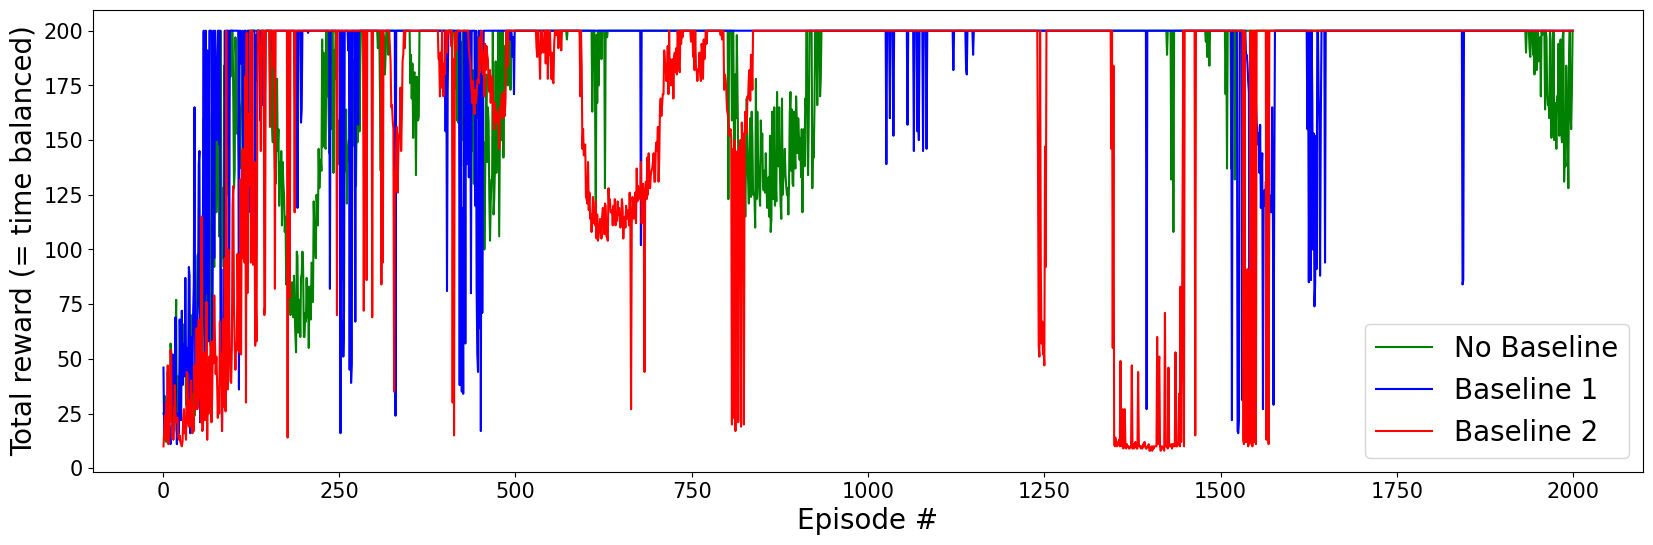

In [55]:
### Plot the learning progress

# Create the plot
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Plot the scores with specified colors and labels
ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='green', label='No Baseline')
ax.plot(np.arange(1, len(scores_baseline_1) + 1), scores_baseline_1, color='blue', label='Baseline 1')
ax.plot(np.arange(1, len(scores_baseline_2) + 1), scores_baseline_2, color='red', label='Baseline 2')

# Set the labels with a larger font size
ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)

# Set the tick labels to a larger font size
ax.tick_params(axis='both', which='major', labelsize=15)

# Add a legend with a specified font size
ax.legend(fontsize=20)

# Show the plot
plt.show()

# $Q^\star$: Policy Gradient with continuous actions and bound on the bonuses count in OPPO (20 points)
***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ 
and covariance matrix $\Sigma$ . Write down the following gradients:

$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = ???$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) = ???$$
***Question 2*** In this exercise, you will bound the state action counts. This is a crucial part of the OPPO convergence proof. Let $N^t_h(s,a)$ denotes the number of times the state action pair $s,a$ has been visited at step $h$ in all the episode up to $t$ included. Moreover,
let $s^t_h,a^t_h$ be the state action pair visited at step $h$ of the $t^{th}$ episode. Then, prove that 
$$ \sum^T_{t=1} \sum^H_{h=1} \frac{1}{N^t_h(s^t_h, a^t_h)+1} \leq SAH \log( T H)$$
***Question 3*** Use the fact above to prove the following bound at slide 30 of Lecture 5. That is, for $\mathrm{bonus}^t_h(s,a) = \frac{H}{\sqrt{N^t_h(s,a)+1}}$ it holds that
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq H^2\sqrt{ SA T \log( T H)}$$

***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ 
and covariance matrix $\Sigma$ . Write down the following gradients:

$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = ???$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) = ???$$

Given the Gaussian policy
$$
\pi_{\mu, \Sigma}(a \mid s) = \mathcal{N}(a \mid \mu, \Sigma),
$$

we want to compute the policy gradients of the expected return $J(\pi_{\mu, \Sigma})$ with respect to both $\mu$ and $\Sigma$.

The log-density is
$$
\log \pi_{\mu, \Sigma}(a) = -\frac{d}{2}\log(2 \pi)- \frac{1}{2}\log |\Sigma| - \frac{1}{2} (a - \mu)^T \Sigma^{-1}(a - \mu)
$$

The Policy Gradient theorem extendes to continuous action by replacing $\Sigma_a$ with $\int da$. The interchange of $\nabla_\theta$ and the integrals is justified by ???????.

**With respect to $\mu$** Only the quadratic term depends on $\mu$ hence:

$$
\nabla_\mu \log \pi_{\mu, \Sigma}(a) = -\frac{1}{2}\nabla_\mu [(a-\mu)^T\Sigma^{-1}(a-\mu)] = \Sigma^{-1}(a-\mu)
$$


**With respect to $\Sigma$** We derive:

\begin{align}
\nabla_\Sigma \log \pi_{\mu, \Sigma}(a) &= - \frac{1}{2} \nabla_\Sigma  [\log |\Sigma|] - \frac{1}{2} \nabla_\Sigma [(a - \mu)^T \Sigma^{-1}(a - \mu)] \\
&=  - \frac{1}{2} \Sigma^{-T} - \frac{1}{2} [-\Sigma^{-1}(a - \mu)(a - \mu)^T \Sigma^{-1}]
\end{align}


By symmetry of $\Sigma$:

\begin{align}
\nabla_\Sigma \log \pi_{\mu, \Sigma}(a) 
&=  - \frac{1}{2} \Sigma^{-1} - \frac{1}{2} [-\Sigma^{-1}(a - \mu)(a - \mu)^T \Sigma^{-1}] \\
&= \frac{1}{2} \Sigma^{-1} [ (a-\mu)(a-\mu^T)-\Sigma]\Sigma^{-1}
\end{align}